In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
# loading the data
df_index = pd.read_csv('../data/economic_index_dataset.csv')


In [4]:
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [5]:
##  drop unncessary columns
df_index.drop(columns=['year', 'month'], inplace=True)

In [6]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
# check for missing values
df_index.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

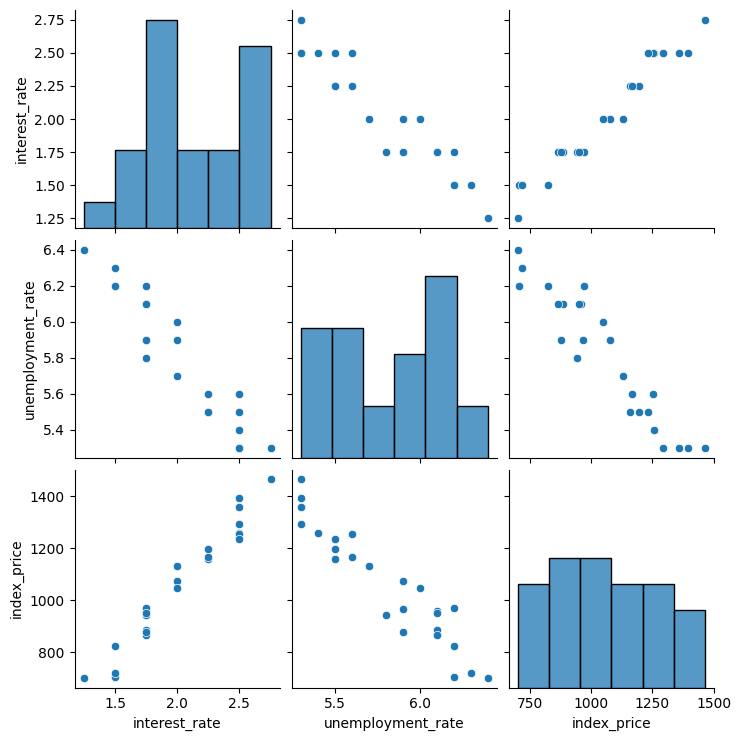

In [9]:
#  visualize the data
import seaborn as sns
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.947256,0.974259
unemployment_rate,-0.947256,1.000000,-0.942822
index_price,0.974259,-0.942822,1.000000


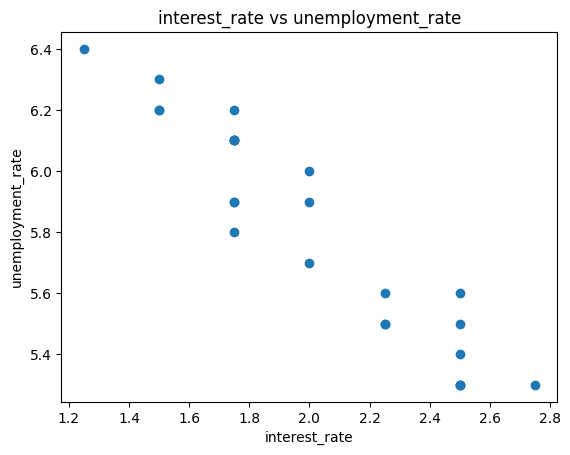

In [11]:
# visualize the data points more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'])
plt.xlabel('interest_rate') 
plt.ylabel('unemployment_rate')
plt.title('interest_rate vs unemployment_rate')
plt.show()

## ML Part

In [12]:
## independent and dependent variables
X = df_index.iloc[:, :-1]
y= df_index.iloc[:, -1]

# X = df_index.drop(columns=['index_price'])
# y = df_index['index_price']

In [13]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [14]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [15]:
## train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

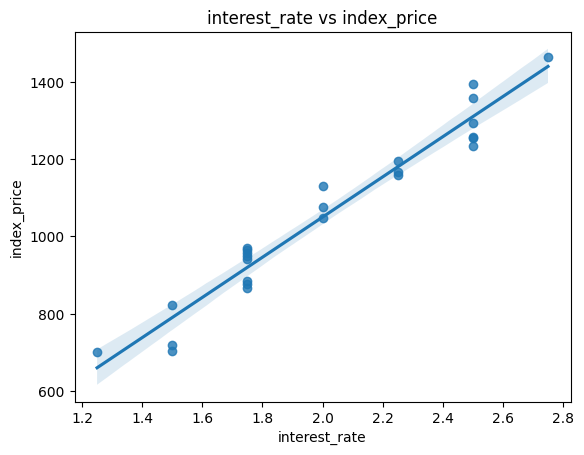

In [17]:
## regplot
sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])
plt.xlabel('interest_rate')
plt.ylabel('index_price')
plt.title('interest_rate vs index_price')
plt.show()

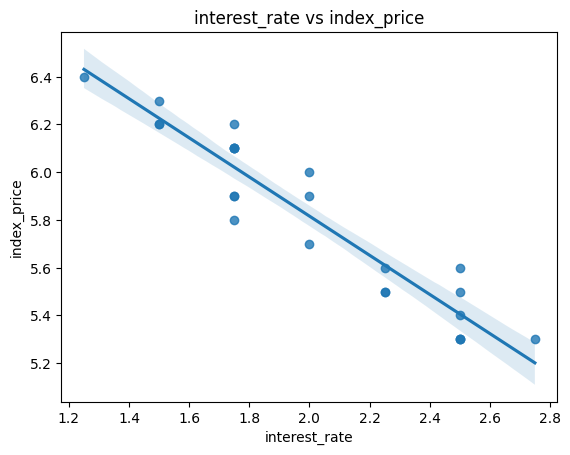

In [18]:
## regplot
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])
plt.xlabel('interest_rate')
plt.ylabel('index_price')
plt.title('interest_rate vs index_price')
plt.show()

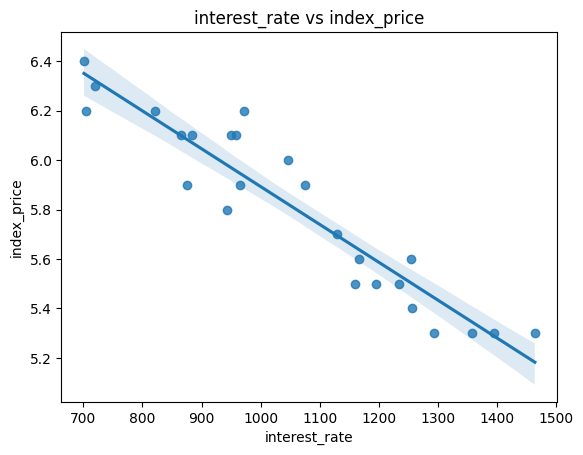

In [20]:
## regplot
sns.regplot(x=df_index['index_price'], y=df_index['unemployment_rate'])
plt.xlabel('interest_rate')
plt.ylabel('index_price')
plt.title('interest_rate vs index_price')
plt.show()

In [21]:
## scaling the features
from sklearn.preprocessing import StandardScaler

In [22]:
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [23]:
X_train

array([[ 1.22474487, -1.43650391],
       [-1.22474487,  1.12078877],
       [ 1.22474487, -0.58407302],
       [ 1.22474487, -1.43650391],
       [ 0.        ,  0.5525015 ],
       [-0.61237244,  0.83664513],
       [ 1.22474487, -1.43650391],
       [ 1.22474487, -1.15236028],
       [-0.61237244,  0.26835787],
       [-0.61237244,  0.83664513],
       [-1.22474487,  1.12078877],
       [-0.61237244,  0.83664513],
       [-1.83711731,  1.68907603],
       [ 0.61237244, -0.86821665],
       [ 0.        , -0.29992939],
       [-0.61237244, -0.01578576],
       [-0.61237244,  0.83664513],
       [ 1.22474487, -0.86821665]])

In [24]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [25]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, 
                                   X_train, y_train,
                                   scoring='neg_mean_squared_error',
                                   cv=3)

In [30]:
validation_score.mean()

np.float64(-3532.9775147933246)

In [32]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([1194.93651276,  884.22873633, 1411.57381531,  775.91008505,
       1030.17557716, 1176.12241798,  940.67102066])

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print('Mean Squared Error', mse)
print('Root Mean Squared Error', rmse)
print('Mean Absolute Error', mae)
print('R-squared', score)

Mean Squared Error 2498.899199874492
Root Mean Squared Error 49.988990786717146
Mean Absolute Error 44.3314094775213
R-squared 0.9447302411392436


## Assumption

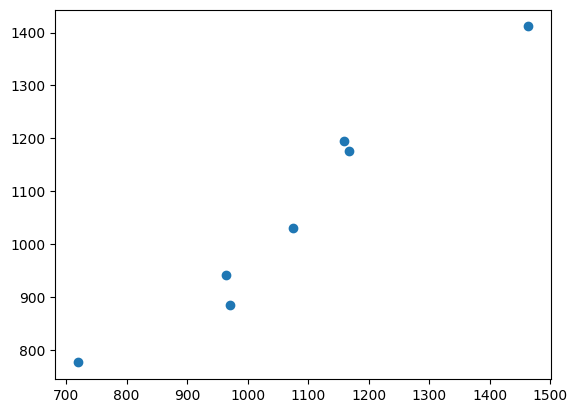

In [35]:
plt.scatter(y_test, y_pred)

In [38]:
residuals = y_test - y_pred
residuals

8    -35.936513
16    86.771264
0     52.426185
23   -56.910085
11    44.824423
9     -9.122418
13    24.328979
Name: index_price, dtype: float64

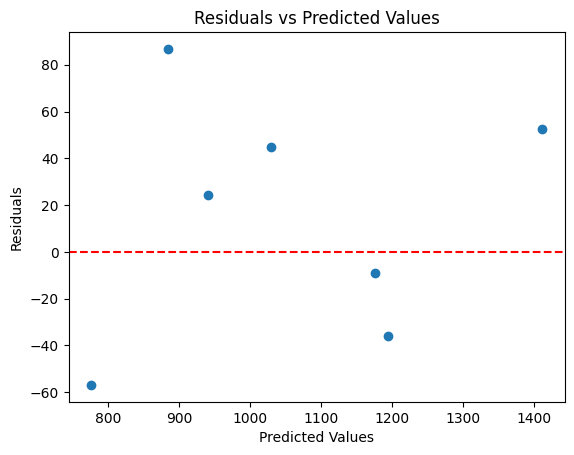

In [39]:
## plot the residuals
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

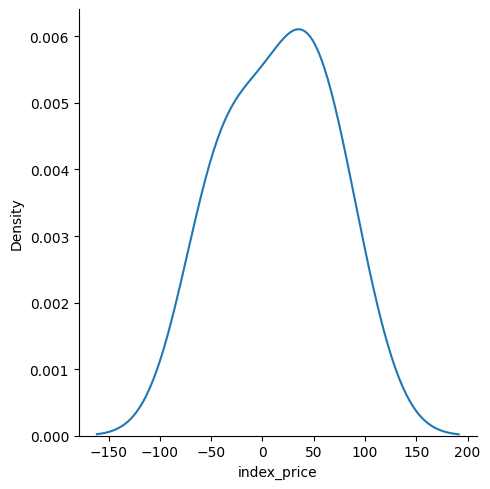

In [42]:
## displot
sns.displot(residuals, kind='kde')

### OLS

In [43]:
import statsmodels.api as sm

In [46]:
model = sm.OLS(y_train, X_train).fit()

In [48]:
prediction = model.predict(X_test)
prediction

array([ 146.99206831, -163.71570811,  363.62937087, -272.03435939,
        -17.76886729,  128.17797354, -107.27342379])

In [50]:
model.summary()

/Users/spy/Desktop/ml-journey/venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.039
Model:                            OLS   Adj. R-squared (uncentered):             -0.082
Method:                 Least Squares   F-statistic:                             0.3205
Date:                Fri, 08 May 2026   Prob (F-statistic):                       0.730
Time:                        19:28:20   Log-Likelihood:                         -150.74
No. Observations:                  18   AIC:                                      305.5
Df Residuals:                      16   BIC:                                      307.3
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1           146.1603    818.941      0.178      0.861   -1589.917    1882.238
x2           -66.2133    818.941     -0.081      0.937   -1802.291    1669.864
==============================================================================
Omnibus:                        1.635   Durbin-Watson:                   0.004
Prob(Omnibus):                  0.442   Jarque-Bera (JB):                0.970
Skew:                          -0.177   Prob(JB):                        0.616
Kurtosis:                       1.920   Cond. No.                         6.08
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [53]:
regression.coef_, regression.intercept_

(array([146.16032872, -66.21332577]), np.float64(1047.9444444444443))

## California Housing Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, r2_score

%matplotlib inline

In [2]:
## loading the datset
california = fetch_california_housing()

In [5]:
type(california)

sklearn.utils._bunch.Bunch

In [6]:
california

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [4]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [7]:
print(california['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
california['target_names']

['MedHouseVal']

In [9]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [10]:
california.target

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [11]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [12]:
## prepare the dataframe
dataset = pd.DataFrame(california.data, columns=california.feature_names)

In [13]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [14]:
dataset['price'] = california.target

In [15]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [16]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [18]:
dataset.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
price         0
dtype: int64

In [20]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
price,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


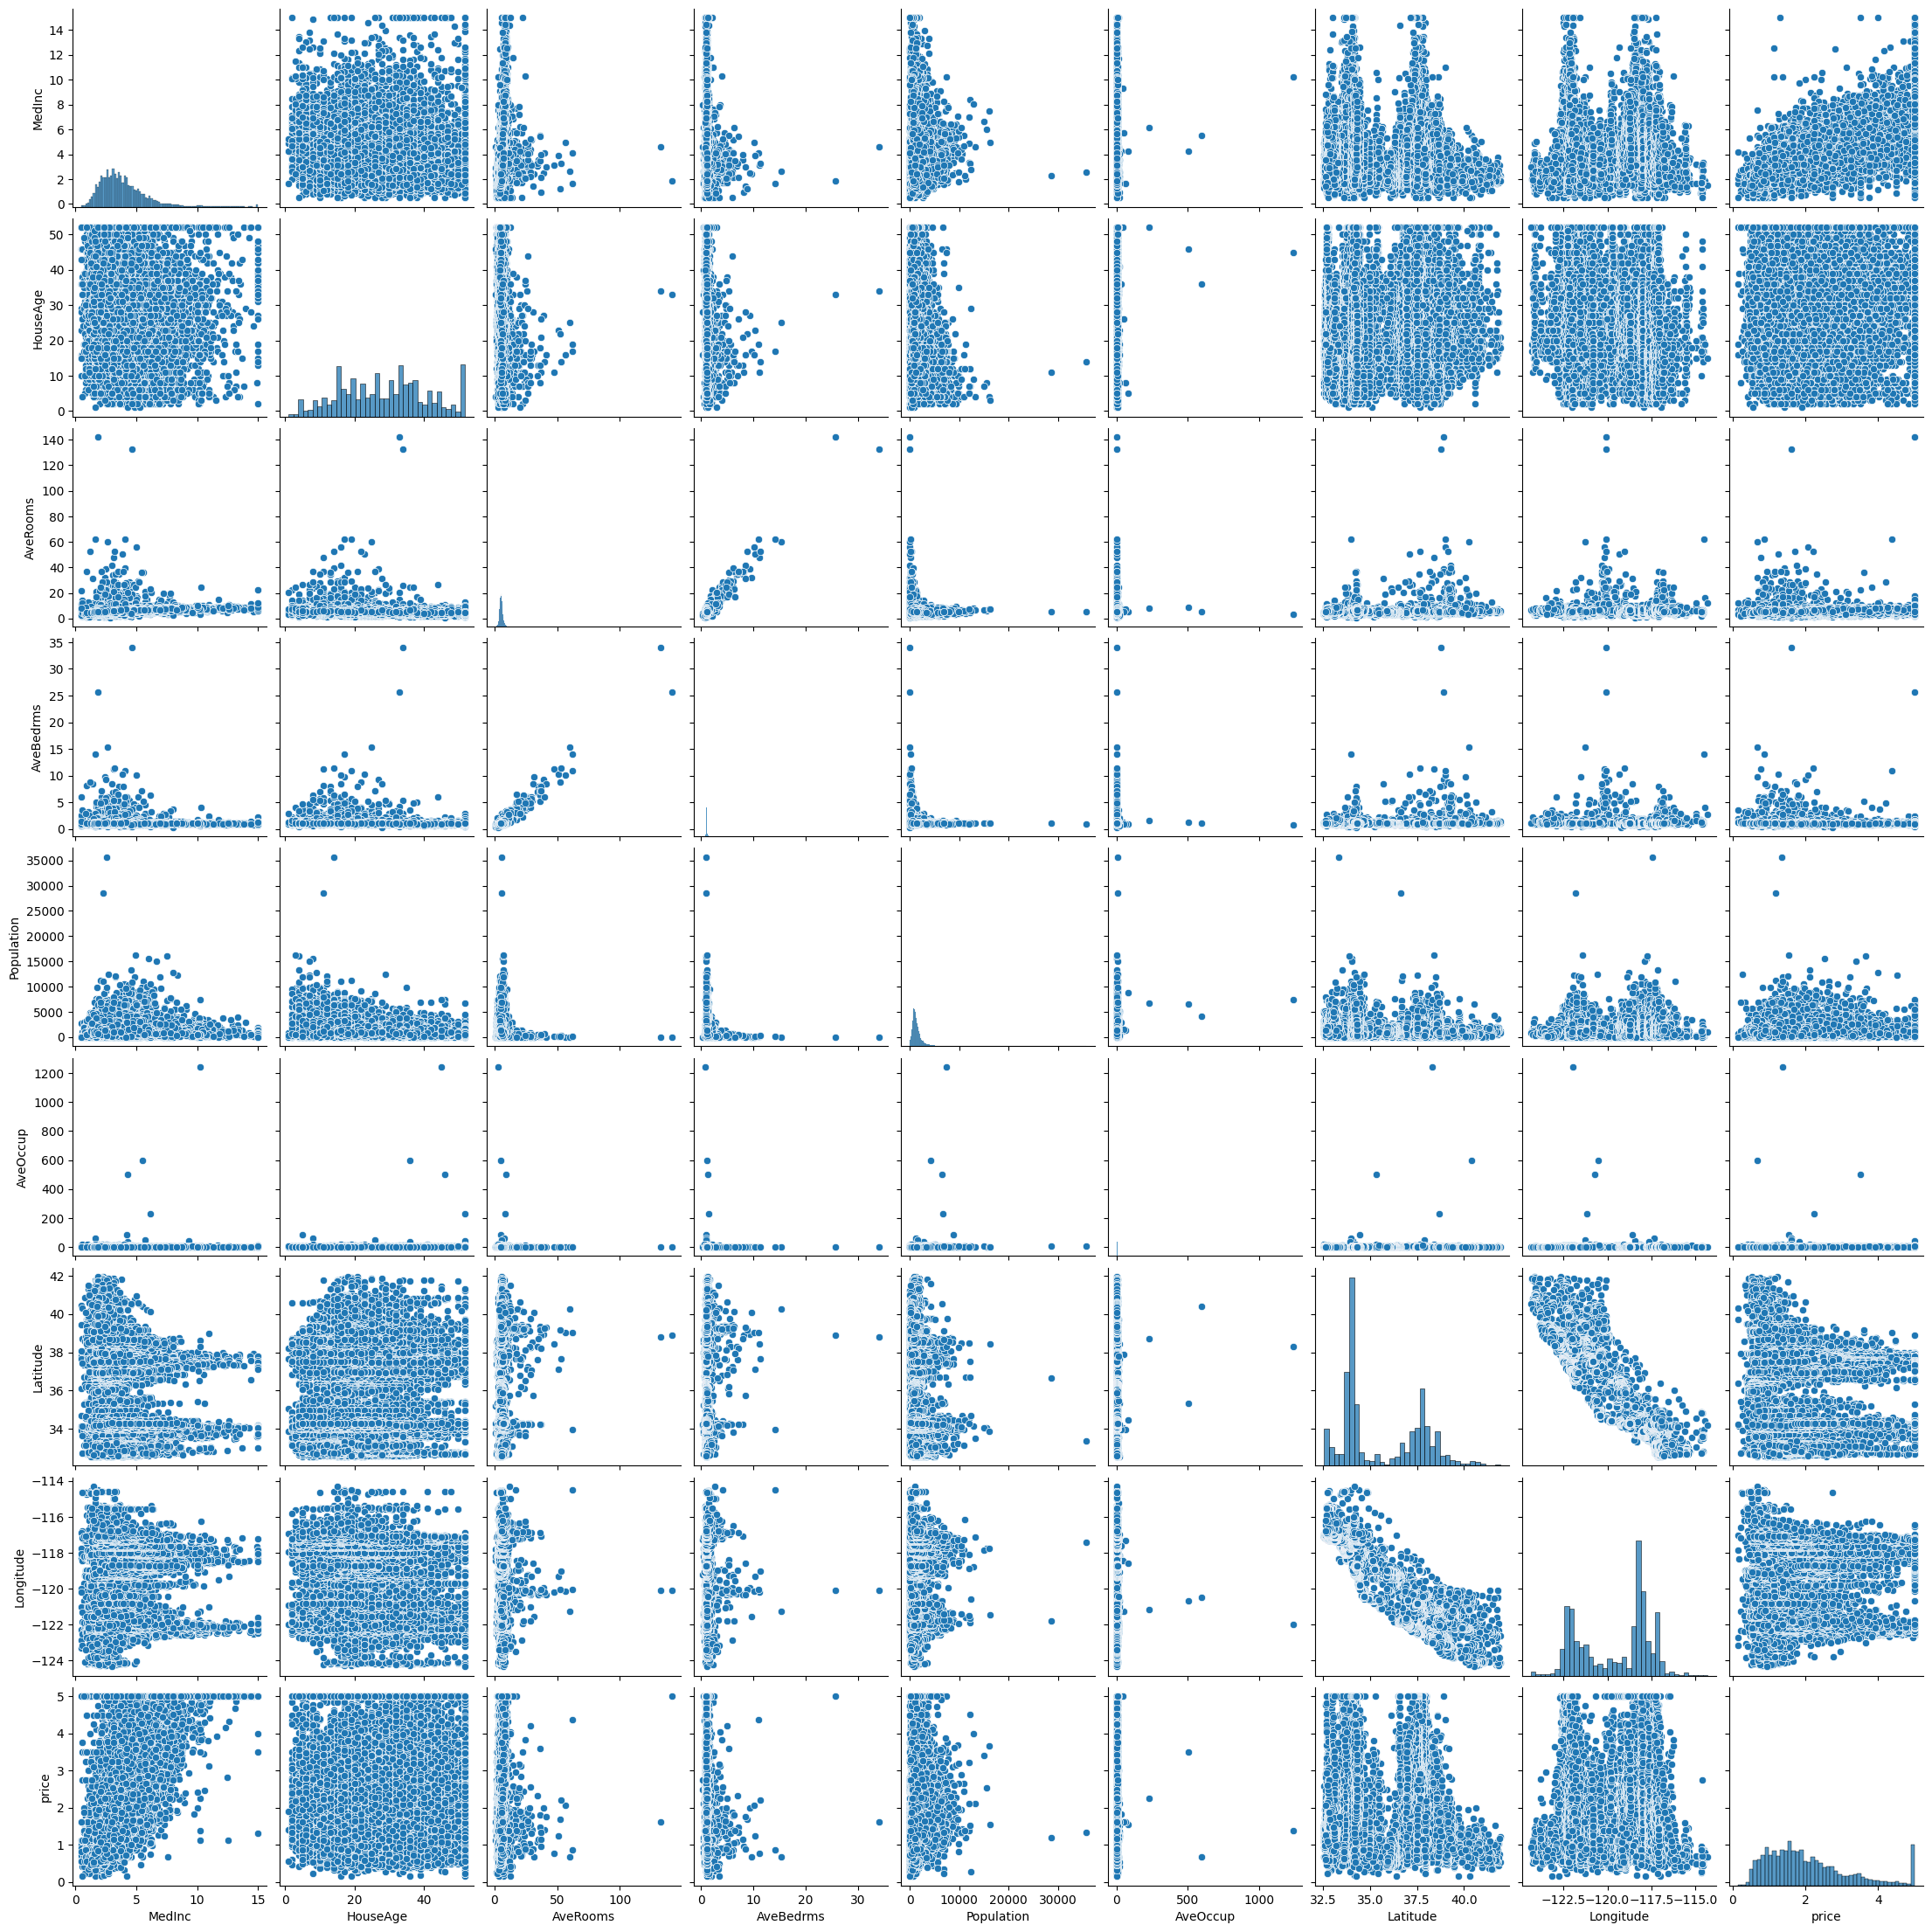

In [21]:
## visualise
sns.pairplot(dataset)

In [22]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

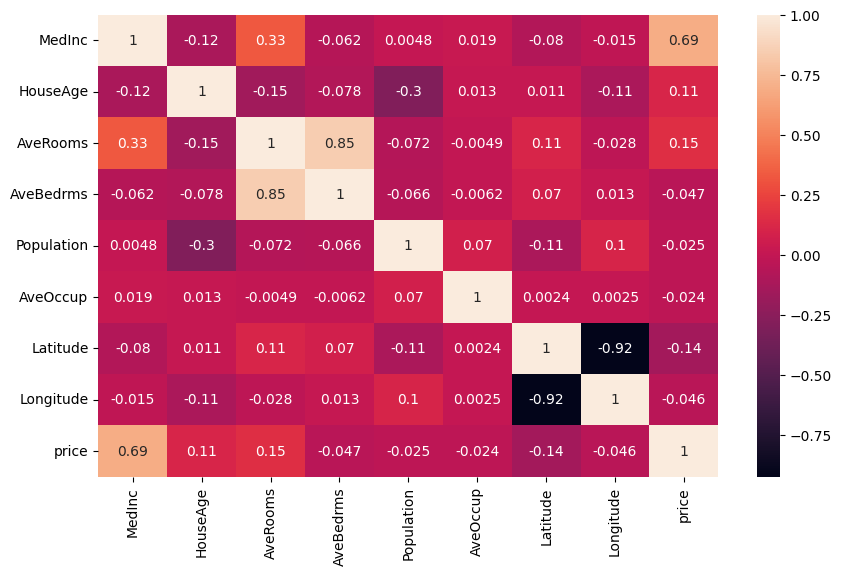

In [25]:
## heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(dataset.corr(), annot=True)

In [26]:
## dividing the data into independent and dependent variables
X = dataset.drop(columns=['price'])
y = dataset['price']

In [28]:
## splittin the data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.33, 
                                                    random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13828, 8), (6812, 8), (13828,), (6812,))

In [29]:
### Feature Scaling or Standardization
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [30]:
X_train

array([[-1.52169954, -0.75868455, -0.91813082, ..., -0.04014979,
        -0.78315293,  0.65090402],
       [ 0.18205382,  0.3523991 ,  0.30748451, ..., -0.05943619,
         0.8475975 , -1.31911678],
       [-0.17232772,  1.06666717, -0.25107784, ...,  0.09515433,
        -0.87218816,  0.66087881],
       ...,
       [-0.49518065,  0.59048846, -0.59192622, ...,  0.01608523,
        -0.75972261,  0.60103008],
       [ 0.96816708, -1.07613702,  0.39144665, ...,  0.0039722 ,
         0.90383028, -1.18445713],
       [-0.68377427,  1.86029835, -0.83041358, ..., -0.08065717,
         0.9928655 , -1.41387727]], shape=(13828, 8))

In [31]:
X_test

array([[-1.15370815, -0.28250584, -0.50803348, ...,  0.05921216,
         0.19154848,  0.28682423],
       [-0.70700034,  0.11430975, -0.16215378, ..., -0.03549556,
        -0.23956945,  0.06239148],
       [-0.20842797,  1.86029835, -0.59583032, ..., -0.13983657,
         1.0069237 , -1.42385206],
       ...,
       [-0.02167353, -1.07613702,  0.40141018, ...,  0.03744641,
         1.43335556, -0.90516304],
       [ 0.27275111, -1.47295261,  0.29311784, ...,  0.0519346 ,
        -0.73160623,  1.09478213],
       [-0.59570436,  1.78093523, -0.64482761, ..., -0.06665881,
         0.99755157, -1.43881424]], shape=(6812, 8))

In [33]:
model = LinearRegression()  
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
## slope or coefficients
model.coef_

array([ 8.46603472e-01,  1.20333548e-01, -2.98800785e-01,  3.47243173e-01,
       -8.81413334e-05, -4.17242067e-02, -8.94420371e-01, -8.70401317e-01])

In [36]:
# Intercept
model.intercept_

np.float64(2.0666362048018536)

In [40]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15316    1.66100
14772    0.93600
12870    1.07000
13476    1.30700
16123    3.07100
Name: price, Length: 6812, dtype: float64

In [37]:
## prediction
y_pred = model.predict(X_test)
y_pred

array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
       2.25826279], shape=(6812,))

In [39]:
## performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print('Mean Squared Error', mse)
print('Root Mean Squared Error', rmse)
print('Mean Absolute Error', mae)
print('R-squared', score)

Mean Squared Error 0.5369686543372459
Root Mean Squared Error 0.7327814505957735
Mean Absolute Error 0.5295710106684453
R-squared 0.5970494128783952


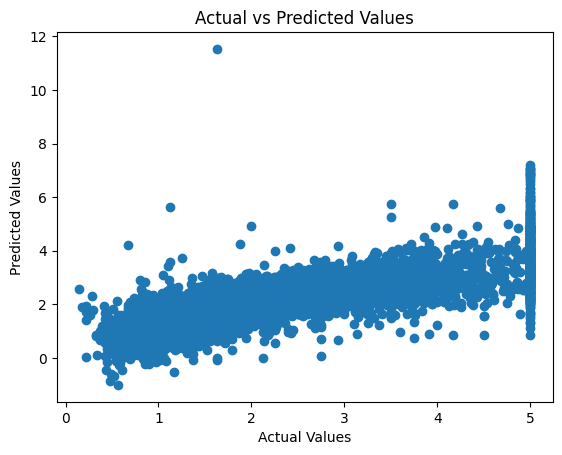

In [41]:
## plotting the predicted vs actual values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [45]:
## y_test vs residuals
residuals = y_test - y_pred
residuals

20046   -0.248635
3024    -1.308502
15663    2.294552
20484   -0.647254
9814     0.175899
           ...   
15316    0.536187
14772   -0.744167
12870   -0.188031
13476   -0.359730
16123    0.812737
Name: price, Length: 6812, dtype: float64

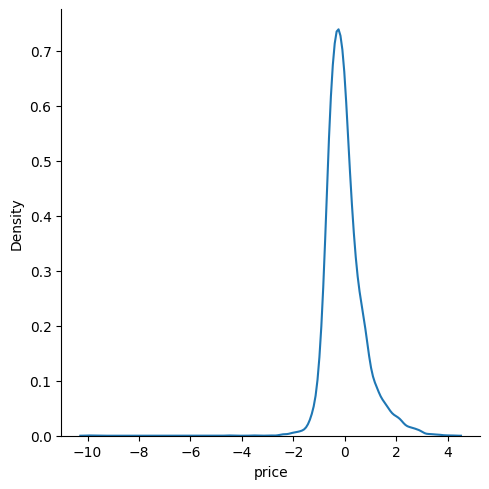

In [46]:
sns.displot(residuals, kind='kde')

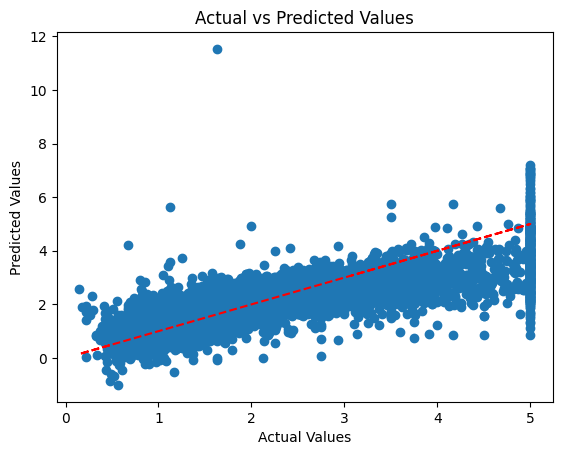

In [44]:
## plot y_test vs y_pred
plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='r', linestyle='--')  # Add a reference line for perfect predictions
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

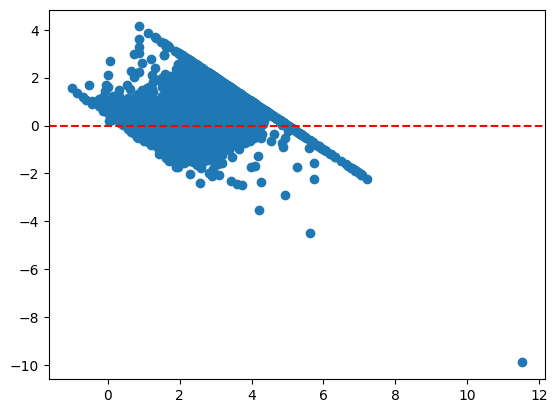

In [48]:
## plot residuals vs predicted values
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')

### pickling
Pickling in Python is the process of converting a Python object hierarchy (like a list, dictionary, or even a custom class) into a byte stream. This allows you to save the object's state to a file or transmit it over a network. Python documentation +3The reverse process—reconstructing the original object from that byte stream—is called unpickling. 

In [49]:
import pickle
pickle.dump(model, open('regressor.pkl', 'wb'))

In [51]:
model = pickle.load(open('regressor.pkl', 'rb'))

In [52]:
model.predict(X_test)

array([0.72563462, 1.76650223, 2.70545812, ..., 1.25803135, 1.66673014,
       2.25826279], shape=(6812,))